---
title: Redes Neuronales Recurrentes con Keras
subject: Aprendizaje Profundo
subtitle: 
short_title: Red recurrente con Keras
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorgeanais/libro_aprendizaje_profundo/blob/main/cap3/030_RNN_Keras.ipynb)

**Objetivo**: En este cuadernillo explorarás las redes neuronales recurrentes (RNN) aplicadas a un problema de predicción de series de tiempo.

Basado en Chollet (2021) *Deep Learning with Python, 2nd Ed.*, capítulo 10.

## <font color="purple">1. Preparativos</font>

In [ ]:
import sys
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print(f"Python     : {sys.version}")
print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")

Python     : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow : 2.19.0
Keras      : 3.13.2


## <font color="purple">2. Pronóstico de temperatura</font>

Trabajaremos con el conjunto de datos [clima de Jena](https://www.kaggle.com/datasets/stytch16/jena-climate-2009-2016), que contiene mediciones meteorológicas registradas cada 10 minutos en Jena, Alemania. El dataset incluye 14 variables (temperatura, presión atmosférica, humedad relativa, velocidad del viento, entre otros).

> **Tarea**:  
Dados los datos de los últimos 5 días (muestreados una vez por hora), ¿podemos predecir la temperatura 24 horas en el futuro?


### <font color="purple">2.1 Descarga y carga de datos</font>

In [ ]:
# Descargamos el dataset de Jena
!wget -q https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip -q jena_climate_2009_2016.csv.zip

replace jena_climate_2009_2016.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace __MACOSX/._jena_climate_2009_2016.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [ ]:
import csv

with open("jena_climate_2009_2016.csv") as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines  = lines[1:]

print(f"Número de variables : {len(header)}")
print(f"Número de registros : {len(lines)}")
print(f"\nVariables:")
for i, col in enumerate(header):
    print(f"  [{i:2d}] {col}")

Número de variables : 15
Número de registros : 420451

Variables:
  [ 0] "Date Time"
  [ 1] "p (mbar)"
  [ 2] "T (degC)"
  [ 3] "Tpot (K)"
  [ 4] "Tdew (degC)"
  [ 5] "rh (%)"
  [ 6] "VPmax (mbar)"
  [ 7] "VPact (mbar)"
  [ 8] "VPdef (mbar)"
  [ 9] "sh (g/kg)"
  [10] "H2OC (mmol/mol)"
  [11] "rho (g/m**3)"
  [12] "wv (m/s)"
  [13] "max. wv (m/s)"
  [14] "wd (deg)"


In [ ]:
# Convertimos a array NumPy
raw_data    = np.zeros((len(lines), len(header) - 1))
temperature = np.zeros((len(lines),))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]   # columna 1 = temperatura (°C)
    raw_data[i, :]  = values

print(f"Forma de raw_data    : {raw_data.shape}")
print(f"Forma de temperature : {temperature.shape}")
print(f"\nTemperatura mín: {temperature.min():.1f} °C")
print(f"Temperatura máx: {temperature.max():.1f} °C")
print(f"Temperatura media: {temperature.mean():.1f} °C")

Forma de raw_data    : (420451, 14)
Forma de temperature : (420451,)

Temperatura mín: -23.0 °C
Temperatura máx: 37.3 °C
Temperatura media: 9.4 °C


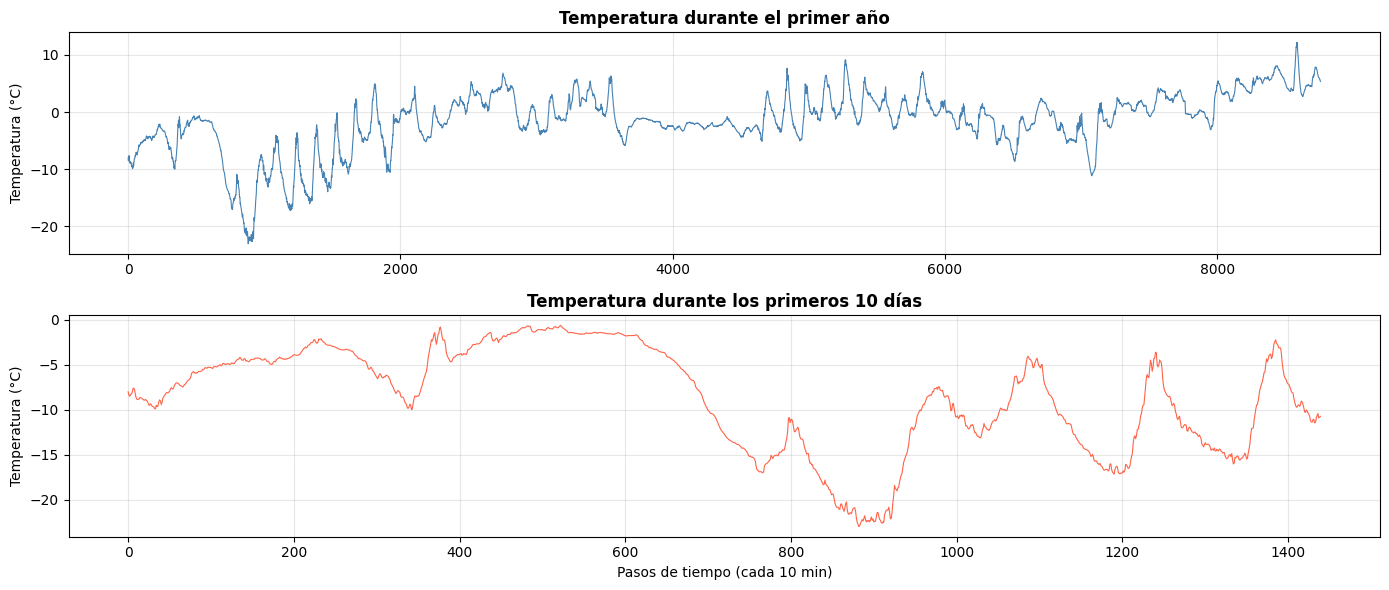

In [ ]:
# Visualizamos la temperatura a lo largo del tiempo
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(temperature[:8760], color="steelblue", linewidth=0.8)
axes[0].set_title("Temperatura durante el primer año", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Temperatura (°C)")
axes[0].grid(alpha=0.3)

axes[1].plot(temperature[:1440], color="tomato", linewidth=0.8)
axes[1].set_title("Temperatura durante los primeros 10 días", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Temperatura (°C)")
axes[1].set_xlabel("Pasos de tiempo (cada 10 min)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### <font color="purple">2.2 Partición del dataset</font>

Dividimos los datos en tres conjuntos:
- Entrenamiento: primer 50% (≈ 210,225 pasos).
- Validación: siguiente 25%.
- Prueba: último 25%.

In [ ]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples   = int(0.25 * len(raw_data))
num_test_samples  = len(raw_data) - num_train_samples - num_val_samples

print(f"Muestras de entrenamiento : {num_train_samples:,}")
print(f"Muestras de validación    : {num_val_samples:,}")
print(f"Muestras de prueba        : {num_test_samples:,}")

Muestras de entrenamiento : 210,225
Muestras de validación    : 105,112
Muestras de prueba        : 105,114


### <font color="purple">2.3 Normalización</font>

Cada variable se mide en escalas muy diferentes (por ejemplo, presión atmosférica ≈ 1000 mbar, humedad relativa ≈ 3 mmol/mol). Normalizamos cada variable independientemente para que todas tomen valores pequeños en una escala similar.

Notar que alculamos la media y la desviación estándar solo sobre los datos de entrenamiento, para evitar fuga de información del futuro.

In [ ]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std  = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

print("Datos normalizados.")
print(f"Media post-normalización (train): {raw_data[:num_train_samples].mean(axis=0).round(4)}")

Datos normalizados.
Media post-normalización (train): [ 0. -0.  0. -0.  0.  0. -0. -0.  0.  0. -0.  0. -0. -0.]


### <font color="purple">2.4 Creación de los datasets con `timeseries_dataset_from_array`</font>

Keras incluye una función utilitaria que genera **ventanas deslizantes** sobre series de tiempo de forma eficiente.

Usaremos los siguientes parámetros:

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `sampling_rate` | 6 | Un punto cada hora (datos cada 10 min × 6 = 1 h) |
| `sequence_length` | 120 | 5 días de historial (120 h) |
| `delay` | `sampling_rate × (sequence_length + 24 − 1)` | Objetivo = temperatura 24 h después del fin de la secuencia |
| `batch_size` | 256 | Tamaño de cada lote |

Cada muestra tiene dimensiones `(120, 14)`: 120 pasos horarios con 14 variables meteorológicas.

In [ ]:
sampling_rate   = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

# Verificación
for samples, targets in train_dataset:
    print(f"Forma de las muestras  : {samples.shape}  → (batch, pasos_de_tiempo, variables)")
    print(f"Forma de los objetivos : {targets.shape}  → (batch,)")
    break

Forma de las muestras  : (256, 120, 14)  → (batch, pasos_de_tiempo, variables)
Forma de los objetivos : (256,)  → (batch,)


## <font color="purple">3. Predicción de sentido común</font>

Antes de entrenar cualquier modelo, establecamos una base que nos permita hacer una comparación posterior. Utilizaremos un modelo ingenuo que consiste en que "*predecir que la temperatura de mañana será exactamente igual a la de hoy a la misma hora*". Esta heurística es sorprendentemente buena para datos de temperatura por su periodicidad diaria.

Evaluaremos con el error absoluto medio (MAE) en grados Celsius. Recuerda que esto métrica mide el promedio del valor absoluto de las diferencias entre el valor predicho por la red y el valor real. Una MAE cercano a 0 quiere decir que la red comete un error muy pequeño, mientras que un error grande quiere decir que la red comete un error grande.

In [ ]:
def evaluate_naive_method(dataset):
    """Predice que la temperatura en 24h = temperatura actual."""
    total_abs_err = 0.
    samples_seen  = 0
    for samples, targets in dataset:
        # La columna 1 contiene la temperatura normalizada.
        # La desnormalizamos multiplicando por std[1] y sumando mean[1].
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen  += samples.shape[0]
    return total_abs_err / samples_seen

val_mae_naive  = evaluate_naive_method(val_dataset)
test_mae_naive = evaluate_naive_method(test_dataset)

print(f"Predicción de sentido común:")
print(f"  MAE validación : {val_mae_naive:.2f} °C")
print(f"  MAE prueba     : {test_mae_naive:.2f} °C")

Línea base de sentido común:
  MAE validación : 2.44 °C
  MAE prueba     : 2.62 °C


Estos valores de Error Absoluto Medio (MAE) establecen nuestra línea base de referencia. Este valor representa el error que se obtiene al aplicar el "modelo ingenuo".

En la práctica, esto significa que la desviación promedio de esta regla con la realidad es de aproximadamente 2.4 °C a 2.6 °C.

En el contexto de nuestras Redes Neuronales Recurrentes (RNN), esperaríamos que cualquier modelo que entrenemos debe obligatoriamente reducir este margen de error. Si la red neuronal reporta un MAE superior a este rango, significa que su capacidad predictiva es inferior a la de nuestro "modelo ingenuo", lo cual no justificaría su complejidad computacional.

## <font color="purple">4. Modelos de referencia (no recurrentes)</font>

Para ampliar nuestra comparación, probaremos dos arquitecturas que no están diseñadas para series de tiempo:
- Una red *feed-forward*.
- Una red convolucional.

Este pequeño experimento intentaremos responder a la pregunta ¿cuál es la mejor arquitectura para tratar con datos recurrentes?

### <font color="purple">4.1 Red densa</font>

Implementamos una red densa de acuerdo a los siguientes parámetros.

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.Flatten()(inputs)
x       = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model_dense = keras.Model(inputs, outputs)
model_dense.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        26,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,913 (105.13 KB)

 Trainable params: 26,913 (105.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_dense = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model_dense.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_dense = model_dense.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks_dense
)
model_dense = keras.models.load_model("jena_dense.keras")
print(f"\nMAE prueba (red densa): {model_dense.evaluate(test_dataset)[1]:.2f} °C")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s 75ms/step - loss: 12.0092 - mae: 2.6815 - val_loss: 11.5605 - val_mae: 2.6929
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s 75ms/step - loss: 8.7797 - mae: 2.3295 - val_loss: 12.2081 - val_mae: 2.7700
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 60s 73ms/step - loss: 8.0457 - mae: 2.2330 - val_loss: 10.9420 - val_mae: 2.6220
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 59s 72ms/step - loss: 7.6254 - mae: 2.1741 - val_loss: 10.9319 - val_mae: 2.6212
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 59s 72ms/step - loss: 7.3210 - mae: 2.1306 - val_loss: 10.5598 - val_mae: 2.5798
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 62s 75ms/step - loss: 7.0955 - mae: 2.0987 - val_loss: 10.9904 - val_mae: 2.6278
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 61s 74ms/step - loss: 6.9211 - mae: 2.0711 - val_loss: 11.3474 - val_mae: 2.6748
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 65s 79ms/step - loss: 6.7760 - mae: 2.0496 - val_loss: 10.6650 - val_mae: 2.5898
Epoch 9/10
819/819 ━━━━━━━━━━━━

### <font color="purple">4.2 Red convolucional 1D</font>

Aquí implementamos una red convolucional con 3 capas convolucionales de acuerdo con el siguiente código.

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.Conv1D(8, 24, activation="relu")(inputs)
x       = layers.MaxPooling1D(2)(x)
x       = layers.Conv1D(8, 12, activation="relu")(x)
x       = layers.MaxPooling1D(2)(x)
x       = layers.Conv1D(8, 6, activation="relu")(x)
x       = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model_conv = keras.Model(inputs, outputs)
model_conv.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 97, 8)          │         2,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 37, 8)          │           776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 18, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 13, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,873 (15.13 KB)

 Trainable params: 3,873 (15.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_conv = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model_conv.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_conv = model_conv.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks_conv
)
model_conv = keras.models.load_model("jena_conv.keras")
print(f"\nMAE prueba (Conv1D): {model_conv.evaluate(test_dataset)[1]:.2f} °C")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 95s 114ms/step - loss: 27.7438 - mae: 4.0216 - val_loss: 16.0881 - val_mae: 3.1920
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 93s 113ms/step - loss: 15.9340 - mae: 3.1649 - val_loss: 14.7715 - val_mae: 3.0366
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 91s 110ms/step - loss: 14.4886 - mae: 3.0167 - val_loss: 15.1643 - val_mae: 3.0582
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 92s 112ms/step - loss: 13.7174 - mae: 2.9346 - val_loss: 14.2129 - val_mae: 2.9844
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 96s 117ms/step - loss: 13.1034 - mae: 2.8675 - val_loss: 15.3239 - val_mae: 3.0989
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 94s 115ms/step - loss: 12.6590 - mae: 2.8201 - val_loss: 15.5473 - val_mae: 3.0973
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 95s 115ms/step - loss: 12.2139 - mae: 2.7714 - val_loss: 14.1314 - val_mae: 2.9585
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 111s 135ms/step - loss: 11.8831 - mae: 2.7356 - val_loss: 16.1781 - val_mae: 3.2023
Epoch 9/10
819/

## <font color="purple">5. Redes Neuronales Recurrentes (RNN)</font>

Finalmente, utilizaremos dos redes recurrentes, una simple (de una única capa recurrente) y otra apilando 3 capas recurrentes.

Recordar que una RNN procesa una secuencia elemento por elemento, manteniendo un estado interno (o memoria de corto plazo) que se actualiza en cada paso de tiempo. A diferencia de las redes densas o convolucionales, una RNN respeta el orden temporal de los datos de forma nativa.

### <font color="purple">5.1 RNN simple (una sola capa)</font>

Construimos el primer modelo recurrente: una sola capa `SimpleRNN` seguida de una capa densa de regresión.

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.SimpleRNN(16)(inputs)   # return_sequences=False por defecto
outputs = layers.Dense(1)(x)
model_rnn = keras.Model(inputs, outputs)
model_rnn.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_rnn = [
    keras.callbacks.ModelCheckpoint("jena_rnn.keras", save_best_only=True)
]
model_rnn.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_rnn = model_rnn.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks_rnn
)
model_rnn = keras.models.load_model("jena_rnn.keras")
print(f"\nMAE prueba (SimpleRNN 1 capa): {model_rnn.evaluate(test_dataset)[1]:.2f} °C")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 97ms/step - loss: 46.5657 - mae: 5.0414 - val_loss: 13.2682 - val_mae: 2.7129
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - loss: 11.3914 - mae: 2.6173 - val_loss: 9.5134 - val_mae: 2.4000
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 98ms/step - loss: 10.3793 - mae: 2.5114 - val_loss: 9.2239 - val_mae: 2.3617
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - loss: 10.1920 - mae: 2.4873 - val_loss: 9.1744 - val_mae: 2.3569
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - loss: 10.0818 - mae: 2.4724 - val_loss: 9.0402 - val_mae: 2.3393
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - loss: 9.9956 - mae: 2.4615 - val_loss: 9.0560 - val_mae: 2.3421
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 83s 101ms/step - loss: 9.9229 - mae: 2.4521 - val_loss: 9.0359 - val_mae: 2.3390
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 84s 102ms/step - loss: 9.8581 - mae: 2.4450 - val_loss: 9.0416 - val_mae: 2.3417
Epoch 9/10
819/819 ━━━━━━━━━━━━━

### <font color="purple">5.2 RNN apiladas (stacked RNN)</font>

Al igual que las redes densas pueden apilarse para aumentar su capacidad representacional, las capas recurrentes también pueden apilarse. Esto permite que la red aprenda representaciones temporales jerárquicas: las capas inferiores captan patrones de corto plazo y las superiores patrones de largo plazo.

Notar que todas las capas intermedias deben usar `return_sequences=True` para pasar la secuencia completa de estados a la siguiente capa. Solo la capa final puede usar `return_sequences=False`.

```
Entrada (batch, 120, 14)
      ↓
SimpleRNN(16, return_sequences=True)  → (batch, 120, 16)
      ↓
SimpleRNN(16, return_sequences=True)  → (batch, 120, 16)
      ↓
SimpleRNN(16)                          → (batch, 16)
      ↓
Dense(1)                               → (batch, 1)
```

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.SimpleRNN(16, return_sequences=True)(inputs)
x       = layers.SimpleRNN(16, return_sequences=True)(x)
x       = layers.SimpleRNN(16)(x)
outputs = layers.Dense(1)(x)
model_stacked = keras.Model(inputs, outputs)
model_stacked.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 120, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 120, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_stacked = [
    keras.callbacks.ModelCheckpoint("jena_stacked_rnn.keras", save_best_only=True)
]
model_stacked.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history_stacked = model_stacked.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks_stacked
)
model_stacked = keras.models.load_model("jena_stacked_rnn.keras")
print(f"\nMAE prueba (SimpleRNN apilada): {model_stacked.evaluate(test_dataset)[1]:.2f} °C")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 137s 164ms/step - loss: 38.1837 - mae: 4.4512 - val_loss: 12.1911 - val_mae: 2.6294
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 133s 162ms/step - loss: 11.0497 - mae: 2.5834 - val_loss: 9.7424 - val_mae: 2.4340
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 131s 160ms/step - loss: 10.2783 - mae: 2.5029 - val_loss: 9.6568 - val_mae: 2.4091
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 133s 162ms/step - loss: 10.0165 - mae: 2.4735 - val_loss: 8.9948 - val_mae: 2.3216
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 133s 161ms/step - loss: 9.8060 - mae: 2.4489 - val_loss: 9.3173 - val_mae: 2.3780
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 140s 171ms/step - loss: 9.5971 - mae: 2.4210 - val_loss: 8.9327 - val_mae: 2.3159
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 138s 168ms/step - loss: 9.3933 - mae: 2.3949 - val_loss: 9.2911 - val_mae: 2.3754
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 136s 166ms/step - loss: 9.2516 - mae: 2.3761 - val_loss: 9.0456 - val_mae: 2.3283
Epoch 9/10
819/819 

## <font color="purple">6. Visualización y comparación de resultados</font>

Graficamos las curvas de entrenamiento y validación de todos los modelos para comparar su comportamiento.

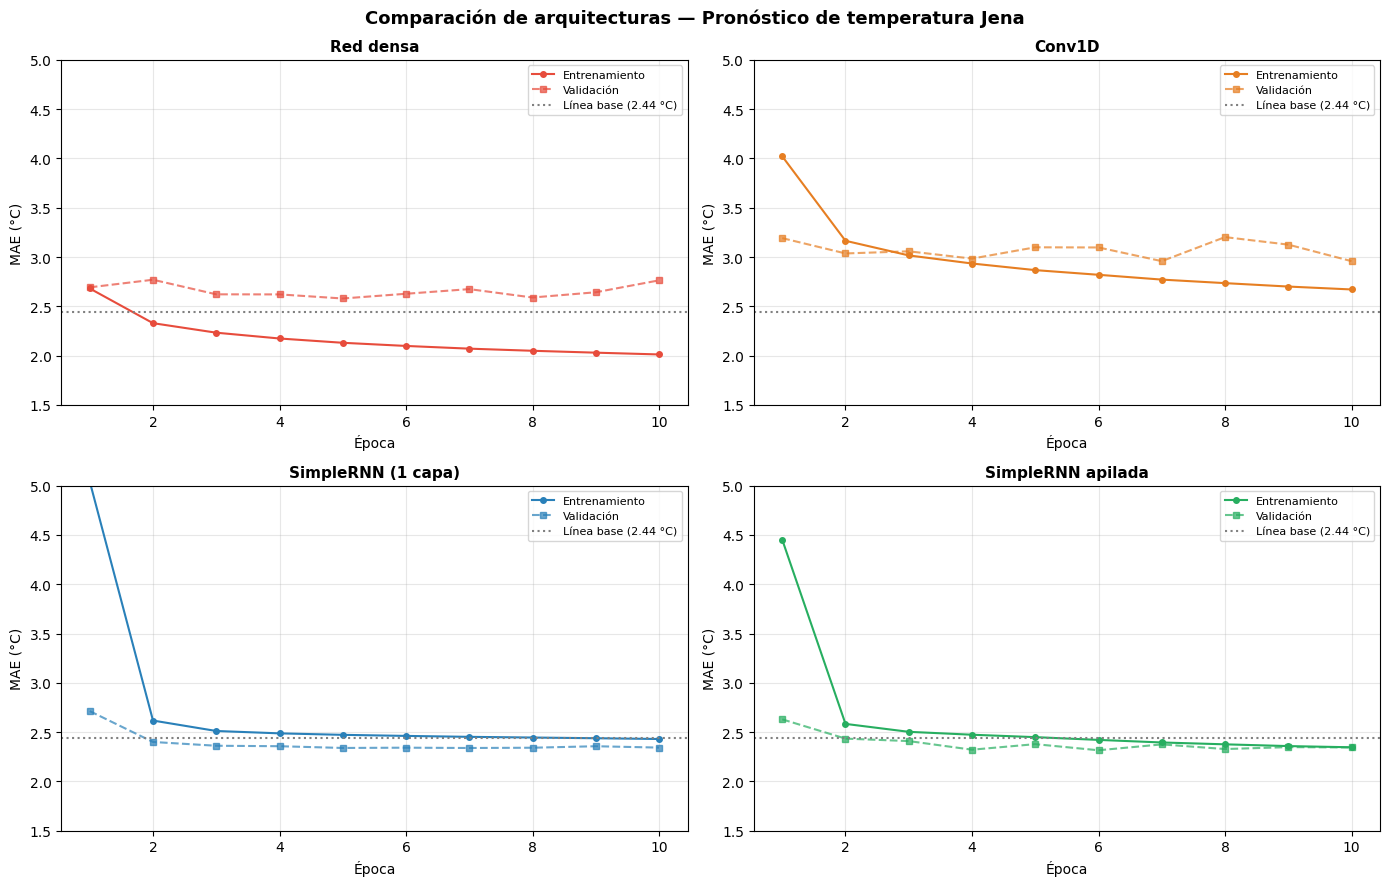

In [ ]:
def plot_history(history, title, ax, color="steelblue"):
    epochs   = range(1, len(history.history["mae"]) + 1)
    ax.plot(epochs, history.history["mae"],     "o-",  color=color,  label="Entrenamiento", markersize=4)
    ax.plot(epochs, history.history["val_mae"], "s--", color=color,  label="Validación",    markersize=4, alpha=0.7)
    ax.axhline(y=val_mae_naive, color="gray", linestyle=":", linewidth=1.5, label=f"Línea base ({val_mae_naive:.2f} °C)")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Época")
    ax.set_ylabel("MAE (°C)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(1.5, 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_history(history_dense,   "Red densa",        axes[0, 0], color="#e74c3c")
plot_history(history_conv,    "Conv1D",            axes[0, 1], color="#e67e22")
plot_history(history_rnn,     "SimpleRNN (1 capa)",axes[1, 0], color="#2980b9")
plot_history(history_stacked, "SimpleRNN apilada", axes[1, 1], color="#27ae60")

plt.suptitle("Comparación de arquitecturas — Pronóstico de temperatura Jena",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---

### <font color="blue">**Ejercicio** Comparación de arquitecturas no recurrentes vs. recurrentes</font>

Observa las curvas de entrenamiento y responde:

<font color="green">1. ¿Por qué la red densa y la Conv1D tienen dificultades para superar la Predicción de sentido común en este problema? Relaciona tu respuesta con la naturaleza de los datos de temperatura.</font>

<font color="green">2. ¿Qué característica fundamental de los datos de series de tiempo sí captura la SimpleRNN y no capturan los modelos anteriores?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>

<strong>1.</strong> La red densa aplana la secuencia (120, 14) a un vector de 1680 elementos, destruyendo completamente la información temporal: el modelo no sabe qué medición es reciente y cuál es antigua. La Conv1D asume <em>invarianza traslacional</em>: trata igual un patrón que aparece en la mañana que uno que aparece en la noche, y sus capas de pooling destruyen adicionalmente el orden. Para la temperatura, el momento del día es crucial: las mediciones recientes son mucho más informativas que las de hace 5 días, algo que ninguno de estos modelos puede aprovechar.

<strong>2.</strong> La SimpleRNN procesa la secuencia <em>en orden</em>, actualizando su estado interno en cada paso de tiempo. Esto le permite aprender que las temperaturas más recientes son más relevantes para la predicción, capturando la dependencia temporal y la causalidad inherente en los datos de series de tiempo.
</p>
</details>

Tu respuesta aquí...